# Homework 2: Generative Models for Inverse Problems

This homework is based on the material of the **generative-model** chapter, with emphasis on the use of learned priors for inverse problems. The goal is to reuse pretrained generative models from the lecture notebooks and study how they can guide reconstruction under a known forward operator, following the broad perspective of learned priors surveyed in {cite}`ongie2020deep,arridge2019solving`.

Starting from clean Mayo images $\{\boldsymbol{x}_i\}_{i=1}^N$, you will generate synthetic measurements of the form

$$
    \boldsymbol{y}_i^\delta = K\boldsymbol{x}_i + \boldsymbol{e},
$$

where $K$ is a known motion-blur operator and $\boldsymbol{e}$ is additive Gaussian noise. You will then compare at least two reconstruction strategies:

- a **generator-range prior** method based on a pretrained **VAE decoder** {cite}`kingma2014auto,bora2017compressed`;
- a **diffusion-prior** method based on the pretrained denoiser from the diffusion notebook {cite}`ho2020denoising,chung2023diffusion`.

The purpose of the assignment is not to reproduce a research paper line by line, but to demonstrate that you understand the algorithmic logic of generative priors: latent-space optimization, data fidelity, denoising guidance, and the tradeoff between realism and measurement consistency.


## Homework Goals and Deliverables

You are asked to complete the notebook and submit the following:

1. A completed version of this notebook with all `TODO` sections filled in.
2. The pretrained weights you reused from the lecture notebooks, together with any additional saved results you produced for this homework.
3. A short written discussion, included at the end of the notebook, answering the conceptual questions.
4. At least one figure comparing the corrupted datum and the final reconstructions produced by your methods on the same test image.

Your work should show that you can:

- build a dataset pipeline consistent with the generative models used in the lectures;
- simulate an inverse problem through a known operator $K$;
- load and reuse pretrained generative models correctly;
- implement a latent-prior reconstruction procedure;
- implement a diffusion-prior reconstruction procedure;
- compare the methods critically rather than only visually.

```{note}
Use grayscale images resized to $64 \times 64$, because this is the resolution used by the VAE, GAN, and diffusion lecture notebooks.
```

```{warning}
Do **not** use external pretrained foundation models, external inverse-problem toolkits, or black-box diffusion pipelines. This includes downloading a ready-made Hugging Face diffusion pipeline instead of reusing the course denoiser. The homework is about reusing and understanding the models developed in this course.
```


## Suggested Structure of the Work

A reasonable workflow is to start from the data and corruption model, then load the pretrained generative models, then implement the reconstruction procedures, and finally compare them on the same examples.

The **mandatory** part of the homework is:

- one **VAE-based latent prior** reconstruction {cite}`kingma2014auto,bora2017compressed`;
- one **diffusion-prior** reconstruction, choosing either a DPS-style or a DiffPIR-style method {cite}`chung2023diffusion,zhu2023diffpir`.

An optional extension is to include a **GAN-based generator prior** or to implement **both** DPS-style and DiffPIR-style diffusion reconstructions and discuss how the comparison changes.

The notebook intentionally leaves several implementation choices open. You are expected to reuse the ideas developed in the lecture notebooks, but not simply copy them without understanding the role of each step.


In [2]:
!git clone https://github.com/NicolasCola7/IPPy.git

Cloning into 'IPPy'...
remote: Enumerating objects: 389, done.
remote: Counting objects: 100% (389/389), done.
remote: Compressing objects: 100% (279/279), done.
remote: Total 389 (delta 188), reused 288 (delta 90), pack-reused 0 (from 0)
Receiving objects: 100% (389/389), 7.24 MiB | 13.78 MiB/s, done.
Resolving deltas: 100% (188/188), done.


In [3]:
!pip install numpy torch torchvision numba astra-toolbox scikit-image Pillow matplotlib cupy-cuda12x tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 21.8 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import glob
import math
import sys
import os
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

repo_path = os.path.abspath('/content/IPPy')
if repo_path not in sys.path:
    sys.path.append(repo_path)

from IPPy import operators
from IPPy import utilities
from IPPy.nn.diffusion import DiffusionUNet, cosine_beta_schedule, extract, denormalize_to_01

book_root = Path('.').resolve()
drive_dir = book_root / "drive" / "MyDrive" / "COMPUTATIONAL_IMAGING"
weights_dir = drive_dir / 'weights'
weights_dir.mkdir(exist_ok=True)
dataset_dir = drive_dir / "Mayo"

device = utilities.get_device()
torch.manual_seed(0)

print('Working device:', device)
print('Weights directory:', weights_dir)


Working device: cuda
Weights directory: /content/drive/MyDrive/COMPUTATIONAL_IMAGING/weights


## Part 1: Data Pipeline, Corruption Model, and Pretrained Models

In this first part, build a dataset for the Mayo images at $64 \times 64$, define the synthetic inverse problem, and load the pretrained generative models from the lecture notebooks.

The objective of this part is to verify that the data pipeline, the corruption model, and the reused weights are all correct **before** the reconstruction procedures are implemented.

Be careful about **architecture compatibility**. The diffusion weights now correspond to the stronger lecture denoiser used in the diffusion notebook, so your `DiffusionUNet` definition must match that notebook exactly when you call `load_state_dict`. In particular, reuse the same configuration (`in_ch=1`, `base_ch=64`, `channel_mults=(1, 2, 4)`, `time_dim=256`, attention enabled at the same levels, and the same diffusion schedule).

You should at least load:

- the pretrained **VAE** from `../weights/VAE.pth`;
- the pretrained **diffusion denoiser** from `../weights/DDPMDenoiser.pth`.

If you attempt the optional extension, you may also load the pretrained **GAN** generator from `../weights/GAN_G_EMA.pth`.


Device: cuda
Training images: 3306
Test images: 327
Weights directory: /content/drive/MyDrive/COMPUTATIONAL_IMAGING/weights


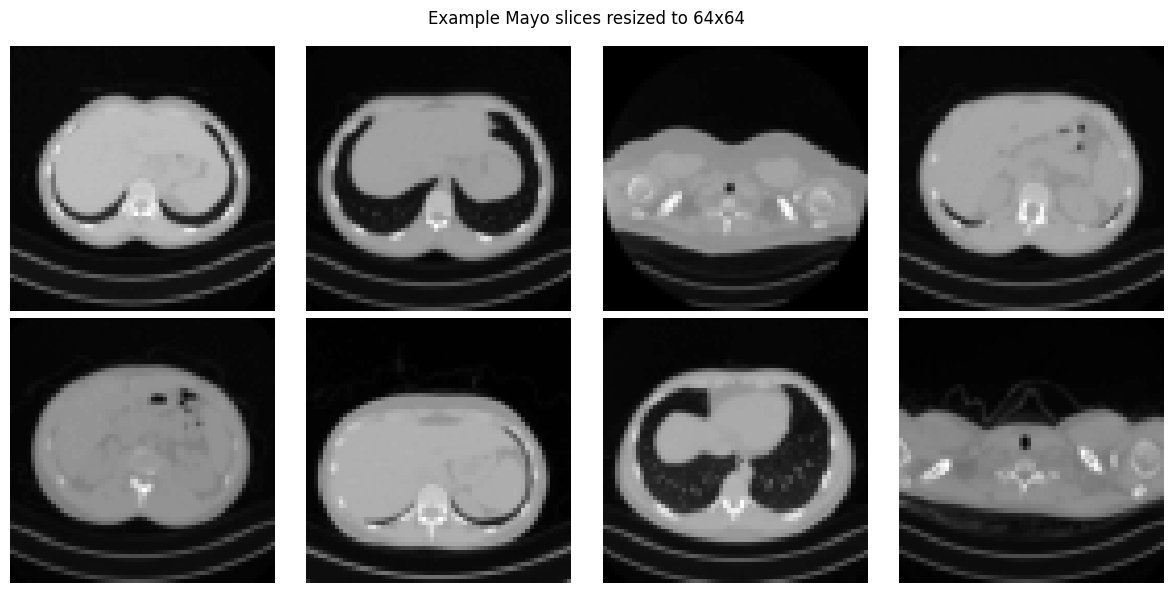

In [6]:
class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape=64):
        super().__init__()
        self.fname_list = sorted(glob.glob(f'{data_path}/*/*.png'))
        self.transform = transforms.Compose([
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
            #transforms.Normalize((0.5,), (0.5,)),
        ])

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        x = Image.open(self.fname_list[idx]).convert('L')
        return self.transform(x)

def show_batch(batch, title, ncols=4):
    batch = batch.detach().cpu()
    n = min(len(batch), 8)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = axes.reshape(-1) if hasattr(axes, 'reshape') else [axes]
    for ax, image in zip(axes, batch[:n]):
        ax.imshow(image.squeeze(), cmap='gray')
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


device = utilities.get_device()
train_dataset = MayoDataset(data_path=str(dataset_dir / 'train'), data_shape=64)
test_dataset = MayoDataset(data_path=str(dataset_dir  / 'test'), data_shape=64)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print('Device:', device)
print('Training images:', len(train_dataset))
print('Test images:', len(test_dataset))
print('Weights directory:', weights_dir)

x_batch = next(iter(train_loader))
show_batch(x_batch[:8], 'Example Mayo slices resized to 64x64')


# TODO:
# 1. Build the training and test datasets and create the dataloaders.
# 2. Define the forward operator K and the additive noise level.
# 3. Visualize at least one clean / corrupted pair.
# 4. Recreate the pretrained model classes from the lecture notebooks
#    and load the VAE and diffusion weights from ../weights/.
#    For the diffusion model, match the lecture architecture exactly
#    and keep the image normalization in [-1, 1].
# 5. If you do the optional extension, also load the GAN generator.


### Define the forward operator K and the additive noise level.

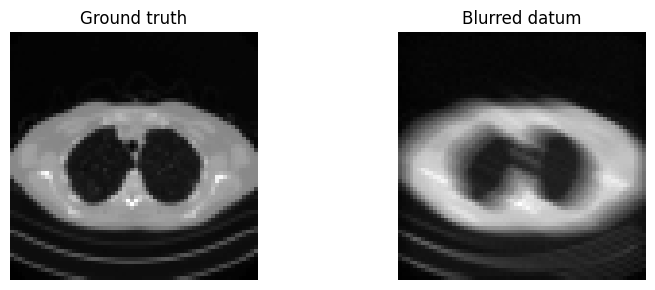

In [7]:
K = operators.Blurring(
    img_shape=(64, 64),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

noise_level = 0.01

with torch.no_grad():
    x_true = test_dataset[0].unsqueeze(0).to(device)
    y_delta = K(x_true)
    y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=noise_level)

    plt.figure(figsize=(12, 3))
    plt.subplot(1, 3, 1)
    plt.imshow(x_true.cpu().squeeze(), cmap='gray')
    plt.title('Ground truth')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(y_delta.cpu().squeeze(), cmap='gray')
    plt.title('Blurred datum')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

### Recreate the pretrained model classes from the lecture notebooks and load the VAE and diffusion weights from ../weights/. For the diffusion model, match the lecture architecture exactly and keep the image normalization in [-1, 1].

In [8]:
# Define a helper function to create a normalization layer given the number of channels
def norm_layer(channels):
    # Set the number of groups to 8 if there are at least 8 channels; otherwise, set it to 1 (which makes it act like Layer Normalization)
    num_groups = 8 if channels >= 8 else 1
    # Initialize and return a PyTorch GroupNorm module with the calculated number of groups and the specified number of channels
    return nn.GroupNorm(num_groups=num_groups, num_channels=channels)


# Define a Residual Block class that inherits from PyTorch's base neural network module
class ResidualBlock(nn.Module):
    # Constructor method that takes the number of input/output channels as an argument
    def __init__(self, channels):
        # Call the parent class (nn.Module) constructor to properly initialize the module
        super().__init__()
        # Group the sequence of layers that make up the residual branch into an nn.Sequential container
        self.block = nn.Sequential(
            # First, apply the custom normalization layer to the input
            norm_layer(channels),
            # Apply the SiLU (Swish) non-linear activation function
            nn.SiLU(),
            # Apply a 2D convolution that maintains the spatial dimensions (padding=1) and channel count
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            # Apply a second normalization layer
            norm_layer(channels),
            # Apply a second SiLU activation function
            nn.SiLU(),
            # Apply a second 2D convolution to finalize the feature transformation for this block
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )

    # Define the forward pass logic for the ResidualBlock
    def forward(self, x):
        # Add the original input (x) to the output of the sequential block to create the residual/skip connection
        return x + self.block(x)


# Define a Downsampling Block class used in the encoder to reduce spatial dimensions
class DownBlock(nn.Module):
    # Constructor taking the number of input channels and the desired number of output channels
    def __init__(self, in_ch, out_ch):
        # Call the parent nn.Module constructor
        super().__init__()
        # Group the downsampling sequence into an nn.Sequential container
        self.block = nn.Sequential(
            # Use a convolution with stride=2 to halve the height and width of the feature map while changing the channel count
            nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
            # Normalize the newly created features
            norm_layer(out_ch),
            # Apply the SiLU activation function
            nn.SiLU(),
            # Pass the features through a ResidualBlock to learn deeper representations at this resolution
            ResidualBlock(out_ch),
        )

    # Define the forward pass logic for the DownBlock
    def forward(self, x):
        # Pass the input tensor through the sequential block and return the downsampled result
        return self.block(x)


# Define an Upsampling Block class used in the decoder to increase spatial dimensions
class UpsampleBlock(nn.Module):
    # Constructor taking the number of input channels and the desired number of output channels
    def __init__(self, in_ch, out_ch):
        # Call the parent nn.Module constructor
        super().__init__()
        # Group the upsampling sequence into an nn.Sequential container
        self.block = nn.Sequential(
            # Double the height and width of the feature map using bilinear interpolation without corner alignment
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            # Apply a convolution to refine the upsampled features and change the channel dimension
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            # Normalize the refined features
            norm_layer(out_ch),
            # Apply the SiLU activation function
            nn.SiLU(),
            # Pass the features through a ResidualBlock to learn deeper representations at this new resolution
            ResidualBlock(out_ch),
        )

    # Define the forward pass logic for the UpsampleBlock
    def forward(self, x):
        # Pass the input tensor through the sequential block and return the upsampled result
        return self.block(x)


# Define the main Convolutional Variational Autoencoder class
class ConvVAE(nn.Module):
    # Constructor taking the size of the latent bottleneck space (default is 64)
    def __init__(self, latent_dim=64):
        # Call the parent nn.Module constructor
        super().__init__()
        # Store the dimension of the latent space as an instance variable
        self.latent_dim = latent_dim

        # Define the initial "stem" of the encoder to process the raw input image
        self.stem = nn.Sequential(
            # Convert a 1-channel (grayscale) input image into a 32-channel feature map, keeping original spatial size
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            # Normalize the 32-channel features
            norm_layer(32),
            # Apply the SiLU activation function
            nn.SiLU(),
            # Pass through an initial ResidualBlock to extract basic visual features
            ResidualBlock(32),
        )
        # First downsampling block: halves spatial size, increases channels from 32 to 64
        self.down1 = DownBlock(32, 64)
        # Second downsampling block: halves spatial size, increases channels from 64 to 128
        self.down2 = DownBlock(64, 128)
        # Third downsampling block: halves spatial size, increases channels from 128 to 256
        self.down3 = DownBlock(128, 256)
        # Fourth downsampling block: halves spatial size, increases channels from 256 to 512
        self.down4 = DownBlock(256, 512)

        # Fully connected layer to map the flattened spatial features to the mean (mu) of the latent distribution
        self.fc_mu = nn.Linear(512 * 4 * 4, latent_dim)
        # Fully connected layer to map the flattened spatial features to the log-variance (logvar) of the latent distribution
        self.fc_logvar = nn.Linear(512 * 4 * 4, latent_dim)
        # Fully connected layer to map the sampled latent vector (z) back to the flattened spatial feature dimension
        self.fc_decode = nn.Linear(latent_dim, 512 * 4 * 4)

        # First upsampling block: doubles spatial size, decreases channels from 512 to 256
        self.up1 = UpsampleBlock(512, 256)
        # Second upsampling block: doubles spatial size, decreases channels from 256 to 128
        self.up2 = UpsampleBlock(256, 128)
        # Third upsampling block: doubles spatial size, decreases channels from 128 to 64
        self.up3 = UpsampleBlock(128, 64)
        # Fourth upsampling block: doubles spatial size, decreases channels from 64 to 32
        self.up4 = UpsampleBlock(64, 32)

        # Final layers to process the upsampled features back into an image format
        self.out_conv = nn.Sequential(
            # Normalize the 32-channel features
            norm_layer(32),
            # Apply the SiLU activation function
            nn.SiLU(),
            # Apply a final convolution to collapse the 32 channels down to 1 channel (reconstructed image)
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            # Apply a Sigmoid activation to squash the output pixel values into the [0, 1] range
            nn.Sigmoid(),
        )

    # Define the encoding pass to get the latent distribution parameters
    def encode(self, x):
        # Pass the input image through the initial stem layers
        h = self.stem(x)
        # Pass through the first downsampling block
        h = self.down1(h)
        # Pass through the second downsampling block
        h = self.down2(h)
        # Pass through the third downsampling block
        h = self.down3(h)
        # Pass through the fourth downsampling block (output is shape [Batch, 512, 4, 4] assuming 64x64 input)
        h = self.down4(h)
        # Flatten the 4D tensor into a 2D matrix (Batch size x flattened features) starting from the channel dimension
        h = h.flatten(start_dim=1)
        # Calculate the latent mean vector (mu)
        mu = self.fc_mu(h)
        # Calculate the log-variance vector, clamping the values to prevent numerical instability (exploding/vanishing variance)
        logvar = self.fc_logvar(h).clamp(min=-4.5, max=1.0)
        # Return both the mean and the log-variance
        return mu, logvar

    # Define the reparameterization trick to allow gradients to flow through the stochastic sampling process
    def reparameterize(self, mu, logvar):
        # Calculate standard deviation by halving the log-variance and exponentiating it: std = exp(0.5 * logvar)
        std = torch.exp(0.5 * logvar)
        # Sample random noise (epsilon) from a standard normal distribution matching the shape of the standard deviation tensor
        eps = torch.randn_like(std)
        # Scale the noise by the standard deviation and add the mean to get the sampled latent vector (z)
        return mu + eps * std

    # Define the decoding pass to reconstruct the image from the latent vector
    def decode(self, z):
        # Map the latent vector to the spatial dimension shape and reshape it back into a 4D tensor [Batch, 512, 4, 4]
        h = self.fc_decode(z).view(z.shape[0], 512, 4, 4)
        # Pass through the first upsampling block
        h = self.up1(h)
        # Pass through the second upsampling block
        h = self.up2(h)
        # Pass through the third upsampling block
        h = self.up3(h)
        # Pass through the fourth upsampling block
        h = self.up4(h)
        # Pass through the final convolutions to generate the reconstructed image and return it
        return self.out_conv(h)

    # Define a helper method for generation that skips the random sampling noise
    def reconstruct_deterministic(self, x):
        # Encode the input image to get the mean (mu), ignoring the log-variance
        mu, _ = self.encode(x)
        # Directly decode the mean (mu) instead of sampling, yielding a deterministic reconstruction
        return self.decode(mu)

    # Define the full forward pass for training the VAE
    def forward(self, x):
        # Encode the input to get the mean and log-variance
        mu, logvar = self.encode(x)
        # Sample the latent vector (z) using the reparameterization trick
        z = self.reparameterize(mu, logvar)
        # Decode the sampled latent vector into the reconstructed image (x_hat)
        x_hat = self.decode(z)
        # Return the reconstructed image, mean, and log-variance (all needed for the loss function)
        return x_hat, mu, logvar


# Define the loss function for the VAE (Reconstruction Loss + KL Divergence)
def vae_loss(x_hat, x, mu, logvar, gamma=5e-4, capacity=0.0):
    # Calculate the L1 (Mean Absolute Error) reconstruction loss between the generated image and original image
    recon_l1 = F.l1_loss(x_hat, x)
    # Calculate the Mean Squared Error (L2) reconstruction loss
    recon_mse = F.mse_loss(x_hat, x)
    # Combine the L1 loss and a scaled down MSE loss to create a robust blended reconstruction loss
    recon = recon_l1 + 0.1 * recon_mse
    # Calculate the Kullback-Leibler (KL) divergence per sample analytically using mu and logvar
    kl_per_sample = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    # Average the KL divergence across the batch size
    kl = kl_per_sample.mean()
    # Calculate the total loss: reconstruction loss + weighted absolute difference between KL and a target capacity (InfoVAE/beta-VAE variant)
    loss = recon + gamma * torch.abs(kl - capacity)
    # Return the total combined loss, the isolated reconstruction loss, and the isolated KL loss (useful for logging)
    return loss, recon, kl

In [9]:
latent_dim = 64
vae_path = weights_dir / 'VAE.pth'
# Instantiate a fresh, untrained ConvVAE model with the same latent dimension to test the loading process
reloaded_vae = ConvVAE(latent_dim=latent_dim)
# Load the saved parameters from disk into the new model instance safely (weights_only=True prevents code execution attacks)
reloaded_vae.load_state_dict(torch.load(vae_path, map_location='cpu', weights_only=True))
# Move the newly loaded model to the compute device
reloaded_vae = reloaded_vae.to(device)
# Set the model to evaluation mode (disables gradient tracking overhead and freezes layers like BatchNorm/Dropout if they existed)
reloaded_vae.eval()

ConvVAE(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (2): SiLU()
    (3): ResidualBlock(
      (block): Sequential(
        (0): GroupNorm(8, 32, eps=1e-05, affine=True)
        (1): SiLU()
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): GroupNorm(8, 32, eps=1e-05, affine=True)
        (4): SiLU()
        (5): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
  )
  (down1): DownBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (2): SiLU()
      (3): ResidualBlock(
        (block): Sequential(
          (0): GroupNorm(8, 64, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (3): GroupNorm(8, 64, eps=1e-05, aff

## Part 2: Latent Reconstruction with a Generator Prior

Use the pretrained **VAE decoder** as a generator prior. The idea is to reconstruct an image by optimizing a latent code $\boldsymbol{z}$ so that the generated image both matches the measurements and remains plausible under the latent prior, in the spirit of deep generative priors for inverse problems {cite}`kingma2014auto,bora2017compressed`.

A standard objective has the form

$$
    \min_{\boldsymbol{z}} \; \|K G(\boldsymbol{z}) - \boldsymbol{y}^\delta\|_2^2 + \lambda \|\boldsymbol{z}\|_2^2,
$$

where $G$ denotes the decoder and $\lambda$ controls the latent regularization.

The mandatory part is to implement the **VAE-based** version. If you want the optional extension, you may implement the same idea with the GAN generator and compare the behavior.


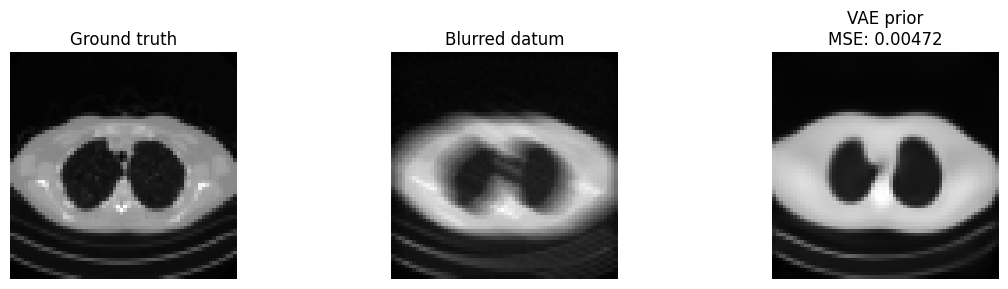

In [10]:
def latent_objective(z, generator, y_delta, K, lam=1e-3):
    # Decode z, apply the forward operator, and compute a latent-prior
    # objective combining data fidelity and latent regularization.
    x_hat = generator(z)
    data_loss = torch.mean((K(x_hat) - y_delta) ** 2)
    prior_loss = lam * torch.mean(z ** 2)
    loss = data_loss + prior_loss

    return loss


def reconstruct_with_vae_prior(generator, y_delta, K, latent_dim, num_steps=500, lr=1e-2, lam=1e-3):
    # Optimize the latent code z and return the final reconstruction.
    z = torch.randn(latent_dim, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([z], lr=lr)

    for _ in range(num_steps):
        loss = latent_objective(z, generator, y_delta, K, lam)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        return generator(z).detach().clamp(0.0, 1.0)


vae_generator = lambda z: reloaded_vae.decode(z)

x_vae = reconstruct_with_vae_prior(vae_generator, y_delta, K, (1, 64), num_steps=500, lr=1e-2, lam=1e-3)

mse_vae = torch.mean((x_vae - x_true) ** 2).item()

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.imshow(x_true.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(y_delta.cpu().squeeze(), cmap='gray')
plt.title('Blurred datum')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(x_vae.cpu().squeeze(), cmap='gray')
plt.title(f'VAE prior\nMSE: {mse_vae:.5f}')
plt.axis('off')

plt.tight_layout()
plt.show()

# TODO:
# Reconstruct at least one corrupted test image with the VAE prior,
# visualize the result, and save any useful intermediate values such
# as the optimized latent code or objective history.


## Part 3: Reconstruction with a Diffusion Prior

Implement one diffusion-prior reconstruction method by reusing the pretrained denoiser from the lecture notebook. Choose either a **DPS-style** method {cite}`chung2023diffusion` or a **DiffPIR-style** method {cite}`zhu2023diffpir`, since these are the two reference examples discussed in the course notebook.

The purpose of this part is to show that you understand how the diffusion model enters the reconstruction algorithm: not through a tractable closed-form prior density, but through denoising or score information used iteratively together with the data-fidelity term.

Use the **same diffusion schedule and denoiser conventions as in the lecture notebook**. In particular, keep the images normalized to `[-1, 1]`, rebuild the denoiser with the correct architecture, and use the matching diffusion schedule when loading `../weights/DDPMDenoiser.pth`.

Keep the implementation compact and readable. It is acceptable to produce a pedagogical version rather than an exact research implementation, provided you explain the choice clearly in your discussion.


In [11]:
DDPM_weigths = weights_dir / 'DDPMDenoiser.pth'


class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape=64):
        super().__init__()
        self.fname_list = sorted(glob.glob(f'{data_path}/*/*.png'))
        self.transform = transforms.Compose([
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        x = Image.open(self.fname_list[idx]).convert('L')
        return self.transform(x)


def make_beta_schedule(num_steps):
    return cosine_beta_schedule(num_steps)


def deterministic_ddim_update(x_t, x0_hat, eps_pred, t_next, alpha_bars):
    if t_next < 0:
        return x0_hat
    alpha_bar_next = alpha_bars[t_next].to(x_t.device)
    return torch.sqrt(alpha_bar_next) * x0_hat + torch.sqrt(1 - alpha_bar_next) * eps_pred


device = utilities.get_device()
num_diffusion_steps = 400
betas = make_beta_schedule(num_diffusion_steps)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

test_dataset = MayoDataset(data_path=str(dataset_dir / 'test'), data_shape=64)
if not DDPM_weigths.exists():
    raise FileNotFoundError(f'Diffusion weights not found at {DDPM_weigths}. Train the previous notebook first.')

model = DiffusionUNet(
    in_ch=1,
    base_ch=64,
    channel_mults=(1, 2, 4),
    time_dim=256,
    dropout=0.05,
    attn_levels=(1, 2),
)
model.load_state_dict(torch.load(DDPM_weigths, map_location='cpu'))
model = model.to(device)
model.eval()

K = operators.Blurring(
    img_shape=(64, 64),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

print('Device:', device)
print('Loaded diffusion weights from:', DDPM_weigths)
print('Diffusion steps:', num_diffusion_steps)

Device: cuda
Loaded diffusion weights from: /content/drive/MyDrive/COMPUTATIONAL_IMAGING/weights/DDPMDenoiser.pth
Diffusion steps: 400


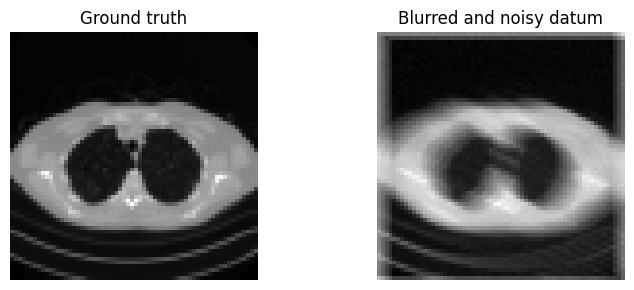

In [12]:
with torch.no_grad():
    x_true = test_dataset[0].unsqueeze(0).to(device)
    y_delta = K(x_true)
    y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=0.01)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(denormalize_to_01(x_true).cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(denormalize_to_01(y_delta).cpu().squeeze(), cmap='gray')
plt.title('Blurred and noisy datum')
plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
def predict_x0_from_eps(x_t, eps_pred, t, alpha_bars):
    # Reconstruct the clean-image estimate from x_t and the predicted noise.
    return (x_t - extract((1 - alpha_bars).sqrt(), t, x_t.shape) * eps_pred) / extract(alpha_bars.sqrt(), t, x_t.shape)

def dps_reconstruct(model, y_delta, K, alpha_bars, sigma_y=0.01, sample_steps=40, guidance_scale=0.15):
    schedule = torch.linspace(num_diffusion_steps - 1, 0, sample_steps, dtype=torch.long, device=device)
    x = torch.randn_like(y_delta)

    for i in range(len(schedule) - 1):
        t_current = int(schedule[i].item())
        t_next = int(schedule[i + 1].item())
        t = torch.full((x.shape[0],), t_current, device=device, dtype=torch.long)

        x = x.detach().requires_grad_(True)
        eps_pred = model(x, t)
        x0_hat = predict_x0_from_eps(x, eps_pred, t, alpha_bars).clamp(-1.0, 1.0)
        data_loss = torch.mean((K(x0_hat) - y_delta) ** 2) / (2 * sigma_y ** 2)
        grad = torch.autograd.grad(data_loss, x)[0]

        with torch.no_grad():
            x_next = deterministic_ddim_update(x, x0_hat, eps_pred, t_next, alpha_bars)
            x = (x_next - guidance_scale * grad).clamp(-1.0, 1.0)

    with torch.no_grad():
        t0 = torch.zeros((x.shape[0],), device=device, dtype=torch.long)
        eps_pred = model(x, t0)
        return predict_x0_from_eps(x, eps_pred, t0, alpha_bars).clamp(-1.0, 1.0).detach()


def diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=0.6):
    schedule = torch.linspace(num_diffusion_steps - 1, 0, sample_steps, dtype=torch.long, device=device)
    x = y_delta.clone()

    for i in range(len(schedule) - 1):
        t_current = int(schedule[i].item())
        t_next = int(schedule[i + 1].item())
        t = torch.full((x.shape[0],), t_current, device=device, dtype=torch.long)

        with torch.no_grad():
            eps_pred = model(x, t)
            x0_hat = predict_x0_from_eps(x, eps_pred, t, alpha_bars).clamp(-1.0, 1.0)
            x_prior = deterministic_ddim_update(x, x0_hat, eps_pred, t_next, alpha_bars)
            residual = K(x_prior) - y_delta
            x = (x_prior - tau * K.T(residual)).clamp(-1.0, 1.0)

    return x.clamp(-1.0, 1.0).detach()


x_diffpir = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=0.6)
x_dps = dps_reconstruct(model, y_delta, K, alpha_bars, sigma_y=0.01, sample_steps=40, guidance_scale=0.15)


# TODO:
# Define the diffusion schedule exactly as in the lecture notebook,
# reconstruct the same corrupted test image used in Part 2, and
# visualize the diffusion-prior result.


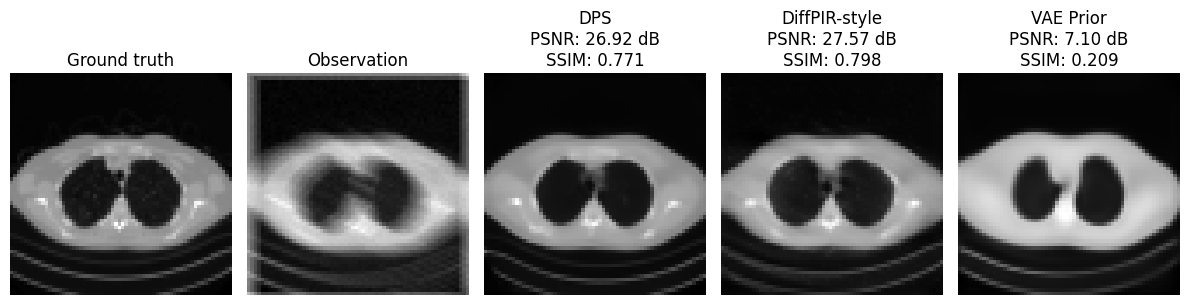

   Observation | MSE: 0.006233 | PSNR: 22.053 dB | SSIM: 0.6298
           DPS | MSE: 0.002032 | PSNR: 26.921 dB | SSIM: 0.7708
 DiffPIR-style | MSE: 0.001752 | PSNR: 27.565 dB | SSIM: 0.7979
     VAE Prior | MSE: 0.195130 | PSNR: 7.097 dB | SSIM: 0.2092


In [19]:
def mse(x, y):
    x_01 = denormalize_to_01(x.detach())
    y_01 = denormalize_to_01(y.detach())
    return torch.mean((x_01 - y_01) ** 2).item()


def psnr(x, y):
    mse_val = mse(x, y)
    return float('inf') if mse_val == 0 else -10 * math.log10(mse_val)


def ssim(x, y, window_size=11, sigma=1.5, c1=0.01 ** 2, c2=0.03 ** 2):
    x_01 = denormalize_to_01(x.detach())
    y_01 = denormalize_to_01(y.detach())
    coords = torch.arange(window_size, device=x_01.device, dtype=x_01.dtype) - window_size // 2
    gauss = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    gauss = gauss / gauss.sum()
    window_2d = torch.outer(gauss, gauss)
    window = window_2d.expand(x_01.shape[1], 1, window_size, window_size).contiguous()
    mu_x = torch.nn.functional.conv2d(x_01, window, padding=window_size // 2, groups=x_01.shape[1])
    mu_y = torch.nn.functional.conv2d(y_01, window, padding=window_size // 2, groups=y_01.shape[1])
    mu_x2 = mu_x ** 2
    mu_y2 = mu_y ** 2
    mu_xy = mu_x * mu_y
    sigma_x2 = torch.nn.functional.conv2d(x_01 * x_01, window, padding=window_size // 2, groups=x_01.shape[1]) - mu_x2
    sigma_y2 = torch.nn.functional.conv2d(y_01 * y_01, window, padding=window_size // 2, groups=y_01.shape[1]) - mu_y2
    sigma_xy = torch.nn.functional.conv2d(x_01 * y_01, window, padding=window_size // 2, groups=x_01.shape[1]) - mu_xy
    ssim_map = ((2 * mu_xy + c1) * (2 * sigma_xy + c2)) / ((mu_x2 + mu_y2 + c1) * (sigma_x2 + sigma_y2 + c2))
    return ssim_map.mean().item()


## Part 4: Visual and Quantitative Comparison

Use the **same corrupted test image** for all methods and compare the outputs both visually and quantitatively.

At a minimum, compute the **MSE**. If you want a richer comparison, also compute **PSNR** and **SSIM**.

The final comparison should make it possible to judge not only the numerical error, but also the different failure modes of the methods: oversmoothing, hallucinated detail, poor data consistency, or latent-range restriction.


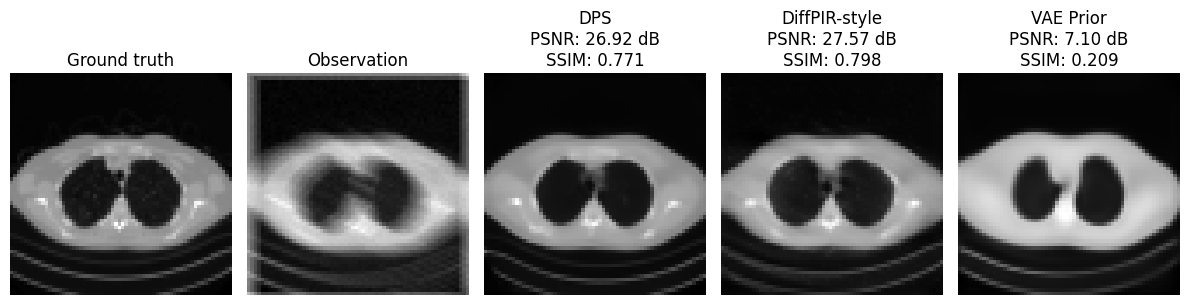

   Observation | MSE: 0.006233 | PSNR: 22.053 dB | SSIM: 0.6298
           DPS | MSE: 0.002032 | PSNR: 26.921 dB | SSIM: 0.7708
 DiffPIR-style | MSE: 0.001752 | PSNR: 27.565 dB | SSIM: 0.7979
     VAE Prior | MSE: 0.195130 | PSNR: 7.097 dB | SSIM: 0.2092


In [20]:

# Evaluate the reconstructed images quantitatively, build a clear
# comparison figure, and comment on the differences between the
# corrupted input, the latent-prior reconstruction, and the
# diffusion-prior reconstruction.
# Helper to print the metric table
results = {
    'Observation': y_delta,
    'VAE Prior': x_vae,
    'DPS': x_dps,
    'DiffPIR-style': x_diffpir,
}

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(denormalize_to_01(x_true.detach()).cpu().squeeze(), cmap='gray')
axes[0].set_title('Ground truth')
axes[0].axis('off')

for ax, (name, image) in zip(axes[1:], results.items()):
    ax.imshow(denormalize_to_01(image.detach()).cpu().squeeze(), cmap='gray')
    if name == 'Observation':
        ax.set_title(name)
    else:
        ax.set_title(f'{name}\nPSNR: {psnr(image, x_true):.2f} dB\nSSIM: {ssim(image, x_true):.3f}')
    ax.axis('off')

plt.tight_layout()
plt.show()

for name, image in results.items():
    print(f'{name:>14} | MSE: {mse(image, x_true):.6f} | PSNR: {psnr(image, x_true):.3f} dB | SSIM: {ssim(image, x_true):.4f}')

## Deliverables and Discussion

Complete the notebook by answering the following questions in a few sentences each.

1. In what sense did the methods balance data consistency and realism?

    The methods achieve this balance mathematically through a "tug-of-war" optimization. The data consistency term (Likelihood) forces the output to match the blurry/noisy measurement obtained from the forward operator. Simultaneously, the learned prior (either the VAE's Gaussian latent penalty or the Diffusion's U-Net score function) pulls the solution toward the manifold of realistic, healthy medical images. The final reconstruction represents an equilibrium between trusting the corrupted sensor physics and trusting the generative model's learned anatomy.

2. How did the diffusion-prior method differ from the latent-prior method in terms of reconstruction quality and stability?
    
    In terms of quality, the diffusion prior is vastly superior; it operates directly in the high-dimensional pixel space, allowing it to recover sharp, high-frequency textures that mimic realistic tissues. The latent prior (VAE) forces the image through a low-dimensional bottleneck, resulting in representation error and overly smooth, blurry reconstructions. However, the VAE optimization is typically much more stable because it navigates a continuous, low-dimensional Gaussian latent space. The diffusion method's step-by-step guidance is highly sensitive to hyperparameters (like guidance scale and step size) and can diverge if the data consistency gradient overpowers the score function.

3. Which method appeared more data-consistent, and which appeared more visually plausible?

    The diffusion method is both more visually plausible and more data-consistent. The VAE is mathematically restricted to the "range of its generator." If its generator cannot produce fine details to perfectly match the measurements, its data consistency loss will hit a floor and stop improving. Because the diffusion model works directly in pixel space, it can micro-adjust individual pixels to mathematically map perfectly back to the measurement $y$, all while using the score function to maintain an incredibly sharp and visually plausible output.

4. Did you observe any signs of hallucination or model bias?

    If yes, how did they manifest themselves?Yes. Hallucinations and bias occur in the "null space" of the forward operator—areas where the blur destroyed all underlying data, forcing the models to guess. In the VAE, bias manifests as a "cartoonification" or over-smoothing of complex textures. In diffusion models, hallucination manifests in a more dangerous way: it can synthesize physically fake structures (e.g., falsely drawing a realistic blood vessel or smoothing over a real anomaly) simply because the U-Net determined it looked statistically normal, overpowering the weak measurement data.

5. Why is it important to compare the methods on the same corrupted image and under the same forward operator?

    Because inverse problems are ill-posed, the specific forward operator $K$ and noise $e$ dictate exactly which anatomical information is permanently lost. By testing on the exact same $y$ and $K$, we mathematically isolate that missing information. This guarantees that any differences observed in the final recovered images are exclusively the result of how the two different generative models inject their prior knowledge to "fill in the blanks."

6. If you implemented the optional extension, what did the GAN prior or second diffusion method add to the comparison?(DPS vs DiffPir):

    Comparing these two reveals the difference between "gradient-based sampling" (DPS) and "proximal/splitting-based guidance" (DiffPIR). DPS essentially forces the generative process to satisfy $y=Ax$ via simple gradients, which is flexible but can be unstable. DiffPIR’s approach is a form of Plug-and-Play (PnP) or regularized inversion that is better at handling the "tug-of-war." The superior SSIM and PSNR for DiffPIR suggest that splitting the problem into a "denoising" step and a "data consistency" step is a more robust way to solve inverse problems than treating the entire measurement process as a single, differentiable constraint.

```{warning}
A reconstruction that looks realistic is not automatically reliable. In inverse problems, generative models can improve plausibility while still violating the measurements or introducing biased details. Your discussion should explicitly address this point.
```
